El presente notebook muestra los resultados de la implementación de un modelo de redes neruonales convolucionales donde se emplean filtros de 3x3 y 5x5 en cada capa y se concatenan las salida para la entrada a la capa siguiente

Importación de librerías

In [1]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D, Conv2DTranspose, Concatenate, Activation # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler  # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

2025-11-17 09:44:41.358452: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-17 09:44:41.373232: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-17 09:44:41.390334: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-17 09:44:41.395354: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-17 09:44:41.408232: I tensorflow/core/platform/cpu_feature_guar

Funciones

In [4]:
# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)


In [2]:
def mostrar_resultados2(
    X, y, y_pred, n=5, cmap='viridis',
    titulo_general="Comparación de Resultados",
    xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):

    n = min(n, len(X))

    # Tamaño de la figura (ajustado para evitar solapamientos)
    fig, axs = plt.subplots(n, 3, figsize=(14, 4.2 * n))

    # Espacio ajustado para evitar traslapes
    fig.subplots_adjust(
        top=0.93,       # espacio superior
        bottom=0.05,
        left=0.05,
        right=0.80,
        hspace=0.35,    # espacio vertical entre filas
        wspace=0     # espacio horizontal entre columnas
    )

    fig.suptitle(titulo_general, fontsize=18)

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}', fontsize=11)
        axs[i, 0].set_xlabel(xlabel, fontsize=10)
        axs[i, 0].set_ylabel(ylabel, fontsize=10)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}', fontsize=11)
        axs[i, 1].set_xlabel(xlabel, fontsize=10)
        axs[i, 1].set_ylabel(ylabel, fontsize=10)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}', fontsize=11)
        axs[i, 2].set_xlabel(xlabel, fontsize=10)
        axs[i, 2].set_ylabel(ylabel, fontsize=10)

    plt.show()

In [12]:
def mostrar_resultados3(
    X, y, y_pred, n=1, cmap='viridis',
    titulo_general="Comparación de Resultados",
    xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):

    n = min(n, len(X))

    # Tamaño de la figura para 1 fila y 3 columnas
    fig, axs = plt.subplots(1, 3, figsize=(14, 4.2))

    # Espacio ajustado para evitar traslapes
    fig.subplots_adjust(
        top=0.85,       # espacio superior reducido
        bottom=0.05,
        left=0.05,
        right=0.80,     # espacio derecho aumentado
        hspace=0.35,    # espacio vertical entre filas
        wspace=0.2      # espacio horizontal entre columnas
    )

    fig.suptitle(titulo_general, fontsize=18)

    # Solo mostramos la primera muestra (i=0)
    i = 0
    
    # Entrada
    axs[0].imshow(X[i, ..., 0], cmap=cmap)
    axs[0].set_title(f'Entrada t={i}', fontsize=11)
    axs[0].set_xlabel(xlabel, fontsize=10)
    axs[0].set_ylabel(ylabel, fontsize=10)

    # Real
    axs[1].imshow(y[i, ..., 0], cmap=cmap)
    axs[1].set_title(f'Real t+1={i+1}', fontsize=11)
    axs[1].set_xlabel(xlabel, fontsize=10)
    axs[1].set_ylabel(ylabel, fontsize=10)

    # Predicción
    axs[2].imshow(y_pred[i, ..., 0], cmap=cmap)
    axs[2].set_title(f'Predicción t+1={i+1}', fontsize=11)
    axs[2].set_xlabel(xlabel, fontsize=10)
    axs[2].set_ylabel(ylabel, fontsize=10)

    plt.show()

In [4]:
# Directorio con imagenes en tamaño original y  tamaño reducido
d_original = '/home/jhon/bandas/banda13/ene_oct_10m'
d_reducida = '/home/jhon/bandas/banda13/ene_oct_10m_reducida'

#Llamado de función para redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas
# Normalización
all_pixels = np.concatenate([img.flatten() for img in images])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images = [(img - global_min) / (global_max - global_min + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida

Procesando 7266 imágenes
Forma de X: (7265, 480, 480, 1)
Forma de y: (7265, 480, 480, 1)


Creación de un modelo simple de redes neuronales convolucionales

In [5]:

# Semilla
semilla = 42
tf.random.set_seed(semilla)

# Entrada
inputs = Input(shape=X.shape[1:])

# === Bloque 1 ===
x1_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(inputs)
x1_5 = Conv2D(16, (5, 5), padding='same', activation='relu')(inputs)

res1 = Concatenate()([x1_3, x1_5])

# === Bloque 2 ===
x2_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(res1)
x2_5 = Conv2D(16, (5, 5), padding='same', activation= 'relu')(res1)

# 🔗 Conexión residual (concatenación)
res2 = Concatenate()([x2_3, x2_5])
res2 = res2 + res1
res2 = Activation('relu')(res2)

# === Bloque 3 ===
x3_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(res2)
x3_5 = Conv2D(16, (5, 5), padding='same', activation= 'relu')(res2)

# 🔗 Conexión residual (concatenación)
res3 = Concatenate()([x3_3, x3_5])
res3 = res3 + res2
res3 = Activation('relu')(res3)

# === Bloque 4 (reducción de canales) ===
x4_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(res3)
x4_5 = Conv2D(16, (5, 5), padding='same', activation='relu')(res3)

# 🔗 Conexión final (concatenación con la salida inicial)
res_final = Concatenate()([x4_3, x4_5])
res_final = res_final + res3
res_final = Activation('relu')(res_final)

# === Salida === Conv 1x1
outputs = Conv2D(1, (1, 1), padding='same', activation='linear')(res_final)

# =====================================================
# PARÁMETROS DEL DECAY COSENOIDAL
# =====================================================
initial_lr = 1e-3       # Tasa de aprendizaje inicial
min_lr = 1e-5           # Tasa mínima al final del entrenamiento
epochs_total = 50       # Debe coincidir con el número de épocas del entrenamiento

# =====================================================
# FUNCIÓN COSINE DECAY (schedule)
# =====================================================
def cosine_decay_schedule(epoch, lr):
    """
    Calcula el decaimiento cosenoidal:
    lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + cos(pi * epoch / total_epochs))
    """
    cosine_decay = 0.5 * (1 + np.cos(np.pi * epoch / epochs_total))
    new_lr = min_lr + (initial_lr - min_lr) * cosine_decay
    return new_lr

# Crear callback de tasa de aprendizaje
lr_scheduler = LearningRateScheduler(cosine_decay_schedule, verbose=1)


# =====================================================
# DEFINICIÓN DEL MODELO
# =====================================================
model12 = Model(inputs=inputs, outputs=outputs)

optimizer = Adam(learning_rate=initial_lr)
model12.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

print("Resumen del modelo:")
model12.summary()

# =====================================================
# CALLBACKS
# =====================================================
checkpoint = ModelCheckpoint(
    filepath="modelo_12_10m_best.h5",
    monitor="val_loss",  # Monitoreamos validación, no entrenamiento
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# =====================================================
# DIVISIÓN CRONOLÓGICA DE DATOS (SERIE DE TIEMPO)
# =====================================================
porc_validacion = 0.2
split_index = int(len(X) * (1 - porc_validacion))

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

print(f"Tamaño entrenamiento: {len(X_train)} muestras")
print(f"Tamaño validación: {len(X_val)} muestras")

# Entrenamiento
print("Iniciando entrenamiento")
history12 = model12.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=4,
    callbacks=[early_stop, checkpoint, lr_scheduler],
    verbose=1
)

print("¡Entrenamiento completado!")
print(f"Pérdida final: {history12.history['loss'][-1]:.4f}")

2025-10-30 21:30:18.172286: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46780 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:52:00.0, compute capability: 8.6


Resumen del modelo:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 480, 480,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 480, 480,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 480, 480,  │        416 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 480, 480,  │          0 │ conv2d[0][0],     │
│ (Concatenate)       │ 32)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 480, 480,  │      4,624 │ concatenate[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 480, 480,  │     12,816 │ concatenate[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 480, 480,  │          0 │ conv2d_2[0][0],   │
│ (Concatenate)       │ 32)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 480, 480,  │          0 │ concatenate_1[0]… │
│                     │ 32)               │            │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 480, 480,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 480, 480,  │      4,624 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 480, 480,  │     12,816 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 480, 480,  │          0 │ conv2d_4[0][0],   │
│ (Concatenate)       │ 32)               │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 480, 480,  │          0 │ concatenate_2[0]… │
│                     │ 32)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 480, 480,  │          0 │ add_1[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 480, 480,  │      4,624 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 480, 480,  │     12,816 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 480, 480,  │          0 │ conv2d_6[0][0], 

 Total params: 52,929 (206.75 KB)

...

1453/1453 ━━━━━━━━━━━━━━━━━━━━ 66s 46ms/step - loss: 0.0055 - mean_absolute_percentage_error: 16.3453 - root_mean_squared_error: 0.0742 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 19.5588 - val_root_mean_squared_error: 0.0832 - learning_rate: 9.0546e-04

Epoch 12: LearningRateScheduler setting learning rate to 0.0008864040551740157.
Epoch 12/50
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0055 - mean_absolute_percentage_error: 16.3442 - root_mean_squared_error: 0.0742
Epoch 12: val_loss did not improve from 0.00693
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 66s 46ms/step - loss: 0.0055 - mean_absolute_percentage_error: 16.3171 - root_mean_squared_error: 0.0741 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 19.5164 - val_root_mean_squared_error: 0.0833 - learning_rate: 8.8640e-04

Epoch 13: LearningRateScheduler setting learning rate to 0.0008658394705735987.
Epoch 13/50
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0055 - mean_absolute_percentage_error: 16.3

1453/1453 ━━━━━━━━━━━━━━━━━━━━ 66s 46ms/step - loss: 0.0055 - mean_absolute_percentage_error: 16.3011 - root_mean_squared_error: 0.0741 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 19.4474 - val_root_mean_squared_error: 0.0832 - learning_rate: 8.6584e-04

Epoch 14: LearningRateScheduler setting learning rate to 0.0008438508174347009.
Epoch 14/50
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0055 - mean_absolute_percentage_error: 16.3096 - root_mean_squared_error: 0.0741
Epoch 14: val_loss improved from 0.00693 to 0.00693, saving model to modelo_12_10m_best.h5


1453/1453 ━━━━━━━━━━━━━━━━━━━━ 66s 46ms/step - loss: 0.0055 - mean_absolute_percentage_error: 16.2803 - root_mean_squared_error: 0.0740 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 19.2792 - val_root_mean_squared_error: 0.0832 - learning_rate: 8.4385e-04

Epoch 15: LearningRateScheduler setting learning rate to 0.0008205248749256015.
Epoch 15/50
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0055 - mean_absolute_percentage_error: 16.2956 - root_mean_squared_error: 0.0741
Epoch 15: val_loss improved from 0.00693 to 0.00691, saving model to modelo_12_10m_best.h5


1453/1453 ━━━━━━━━━━━━━━━━━━━━ 66s 45ms/step - loss: 0.0055 - mean_absolute_percentage_error: 16.2653 - root_mean_squared_error: 0.0740 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 19.4047 - val_root_mean_squared_error: 0.0831 - learning_rate: 8.2052e-04

Epoch 16: LearningRateScheduler setting learning rate to 0.0007959536998847743.
Epoch 16/50
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0055 - mean_absolute_percentage_error: 16.2782 - root_mean_squared_error: 0.0740
Epoch 16: val_loss improved from 0.00691 to 0.00690, saving model to modelo_12_10m_best.h5


1453/1453 ━━━━━━━━━━━━━━━━━━━━ 66s 45ms/step - loss: 0.0055 - mean_absolute_percentage_error: 16.2467 - root_mean_squared_error: 0.0739 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 19.4548 - val_root_mean_squared_error: 0.0831 - learning_rate: 7.9595e-04

Epoch 17: LearningRateScheduler setting learning rate to 0.0007702342635146033.
Epoch 17/50
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0055 - mean_absolute_percentage_error: 16.2666 - root_mean_squared_error: 0.0740
Epoch 17: val_loss did not improve from 0.00690
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 66s 45ms/step - loss: 0.0055 - mean_absolute_percentage_error: 16.2321 - root_mean_squared_error: 0.0739 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 19.4097 - val_root_mean_squared_error: 0.0831 - learning_rate: 7.7023e-04

Epoch 18: LearningRateScheduler setting learning rate to 0.000743468068680349.
Epoch 18/50
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0055 - mean_absolute_percentage_error: 16.25

Valores de las metricas

RESUMEN DE MÉTRICAS
Entrenamiento - Loss final: 0.0054, RMSE final: 0.0736, MAPE final: 16.1132
Validación    - Loss final: 0.0069, RMSE final: 0.0831, MAPE final: 19.1497


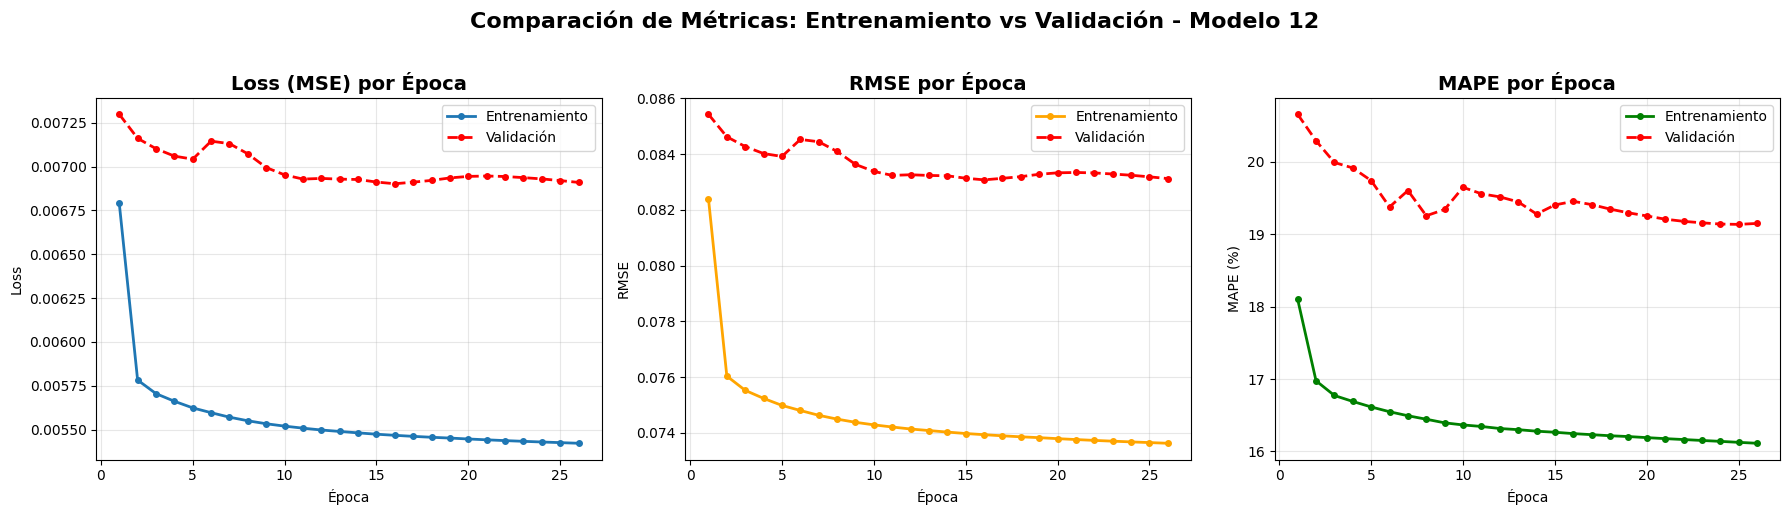

In [6]:
import matplotlib.pyplot as plt

# Extraer métricas del historial (entrenamiento y validación)
loss = history12.history['loss']
val_loss = history12.history['val_loss']

rmse = history12.history['root_mean_squared_error']
val_rmse = history12.history['val_root_mean_squared_error']

mape = history12.history['mean_absolute_percentage_error']
val_mape = history12.history['val_mean_absolute_percentage_error']

epochs = range(1, len(loss) + 1)

# Mostrar resumen final
print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(f"Entrenamiento - Loss final: {loss[-1]:.4f}, RMSE final: {rmse[-1]:.4f}, MAPE final: {mape[-1]:.4f}")
print(f"Validación    - Loss final: {val_loss[-1]:.4f}, RMSE final: {val_rmse[-1]:.4f}, MAPE final: {val_mape[-1]:.4f}")
print("=" * 50)

# =============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# =============================================================================

plt.figure(figsize=(18, 5))

# Gráfico 1: Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: RMSE
plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_rmse, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('RMSE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: MAPE
plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_mape, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('MAPE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Comparación de Métricas: Entrenamiento vs Validación - Modelo 12',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model12.evaluate(X_train, y_train, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

182/182 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - loss: 0.0054 - mean_absolute_percentage_error: 16.0965 - root_mean_squared_error: 0.0738
Pérdida (MSE): 0.0054
RMSE: 0.0738
MAPE: 16.0965


In [8]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model12.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 0.0069 - mean_absolute_percentage_error: 19.4541 - root_mean_squared_error: 0.0831
Pérdida (MSE): 0.0069
RMSE: 0.0831
MAPE: 19.4541


Visualización de imagenes

182/182 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step


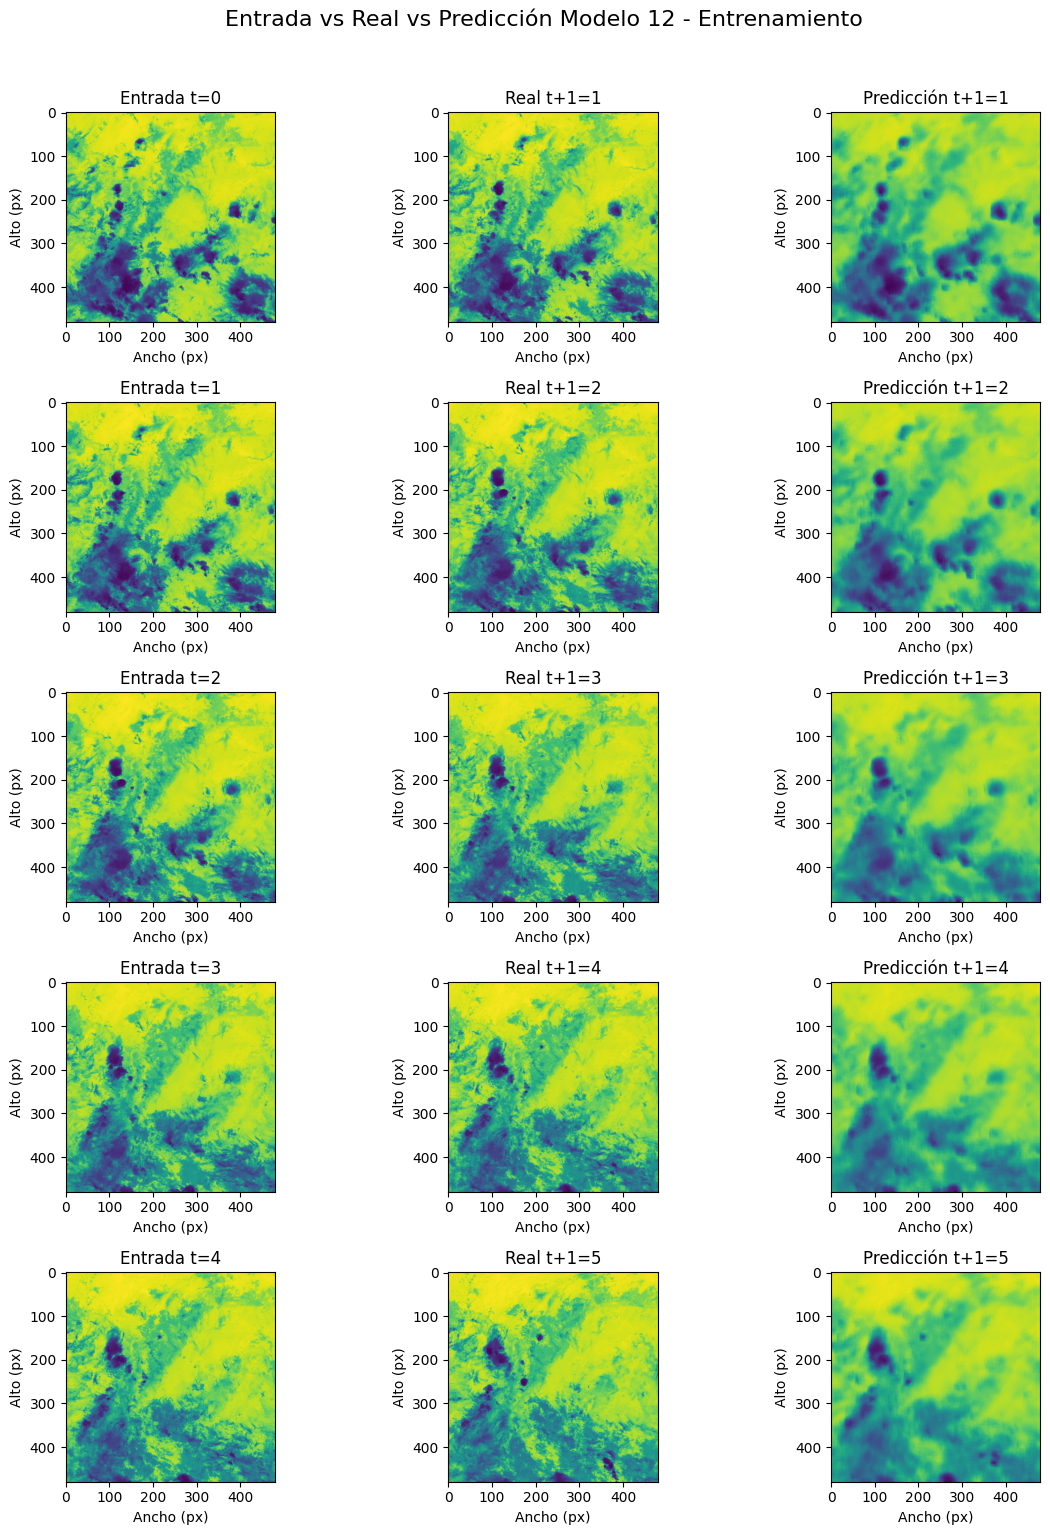

In [9]:
y_pred12 = model12.predict(X_train)  # Genera las predicciones
mostrar_resultados(
    X_train, y_train, y_pred12, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 12 - Entrenamiento",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

Prueba:

In [5]:
# Directorio original y reducido para validación
d_mar_2s_red = '/home/jhon/bandas/banda13/nov_dic_2m_red'

# Llamar a la función para redimensionar imágenes

# Cargar imágenes de validación
file_list_test = sorted([f for f in os.listdir(d_mar_2s_red) if f.endswith('.npy')])
print(f"Procesando {len(file_list_test)} imágenes para validación")

images_test = [np.load(os.path.join(d_mar_2s_red, f)) for f in file_list_test]

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images_test])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images_test = [(img - global_min) / (global_max - global_min + 1e-8) for img in images_test]
images_test = [np.clip(img, 0, 1) for img in images_test]


X_test = np.array(images_test[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_test = np.array(images_test[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_test.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_test.shape}")  # Imprime la forma del array de salida


Procesando 1447 imágenes para validación
Forma de X: (1446, 480, 480, 1)
Forma de y: (1446, 480, 480, 1)


Metricas de testeo

In [ ]:
# Obtener las métricas del modelo en el conjunto de test
loss, rmse, mape = model12.evaluate(X_base_test, y_base_test, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.0048 - mean_absolute_percentage_error: 14.7126 - root_mean_squared_error: 0.0693
Pérdida (MSE): 0.0048
RMSE: 0.0693
MAPE: 14.7126


Visualización de imagenes con conjunto de prueba

46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step


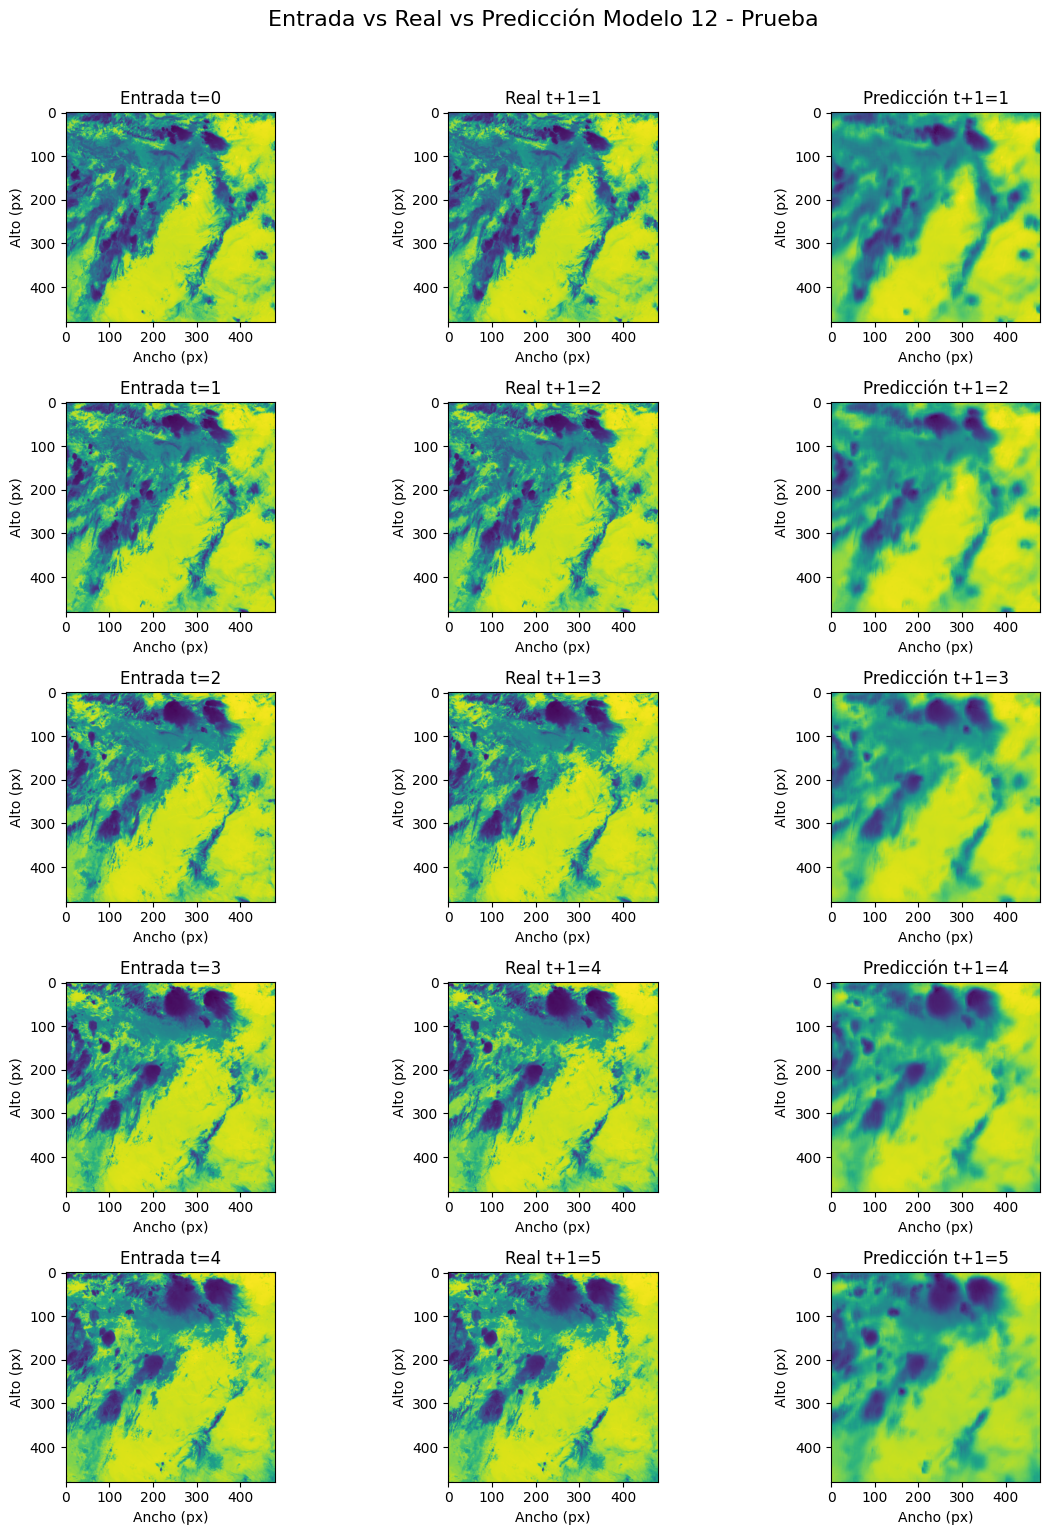

In [15]:
y_pred12_test = model12.predict(X_base_test)  # Genera las predicciones
mostrar_resultados(
    X_base_test, y_base_test, y_pred12_test, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 12 - Prueba",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

In [4]:
from tensorflow.keras.models import load_model
# Cargar el mejor modelo guardado
modelo_cargado = load_model("modelo_12_10m_best.h5", compile=False)



TypeError: too many positional arguments

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *

# Reconstruye con 1 canal de entrada (como el modelo original)
inputs = Input(shape=(None, None, 1))  # ← CAMBIO IMPORTANTE: 1 canal en lugar de 3

# === Bloque 1 ===
x1_3 = Conv2D(16, (3, 3), padding='same', activation='relu', name='conv2d')(inputs)
x1_5 = Conv2D(16, (5, 5), padding='same', activation='relu', name='conv2d_1')(inputs)
res1 = Concatenate()([x1_3, x1_5])

# === Bloque 2 ===
x2_3 = Conv2D(16, (3, 3), padding='same', activation='relu', name='conv2d_2')(res1)
x2_5 = Conv2D(16, (5, 5), padding='same', activation='relu', name='conv2d_3')(res1)
res2 = Concatenate()([x2_3, x2_5])
res2 = res2 + res1
res2 = Activation('relu')(res2)

# === Bloque 3 ===
x3_3 = Conv2D(16, (3, 3), padding='same', activation='relu', name='conv2d_4')(res2)
x3_5 = Conv2D(16, (5, 5), padding='same', activation='relu', name='conv2d_5')(res2)
res3 = Concatenate()([x3_3, x3_5])
res3 = res3 + res2
res3 = Activation('relu')(res3)

# === Bloque 4 ===
x4_3 = Conv2D(16, (3, 3), padding='same', activation='relu', name='conv2d_6')(res3)
x4_5 = Conv2D(16, (5, 5), padding='same', activation='relu', name='conv2d_7')(res3)
res_final = Concatenate()([x4_3, x4_5])
res_final = res_final + res3
res_final = Activation('relu')(res_final)

# === Salida ===
outputs = Conv2D(1, (1, 1), padding='same', activation='linear', name='conv2d_8')(res_final)

modelo_reconstruido = Model(inputs=inputs, outputs=outputs)

# Ahora debería funcionar
modelo_reconstruido.load_weights("modelo_12_10m_best.h5")
print("✅ Pesos cargados exitosamente!")

✅ Pesos cargados exitosamente!


In [7]:
# Directorio original y reducido para validación
d_mar_2s_red = '/home/jhon/bandas/banda13/nov_dic_2m_red'

# Llamar a la función para redimensionar imágenes

# Cargar imágenes de validación
file_list_test = sorted([f for f in os.listdir(d_mar_2s_red) if f.endswith('.npy')])
print(f"Procesando {len(file_list_test)} imágenes para validación")

images_test = [np.load(os.path.join(d_mar_2s_red, f)) for f in file_list_test]

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images_test])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images_test = [(img - global_min) / (global_max - global_min + 1e-8) for img in images_test]
images_test = [np.clip(img, 0, 1) for img in images_test]


X_test = np.array(images_test[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_test = np.array(images_test[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_test.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_test.shape}")  # Imprime la forma del array de salida


Procesando 1447 imágenes para validación
Forma de X: (1446, 480, 480, 1)
Forma de y: (1446, 480, 480, 1)


46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step


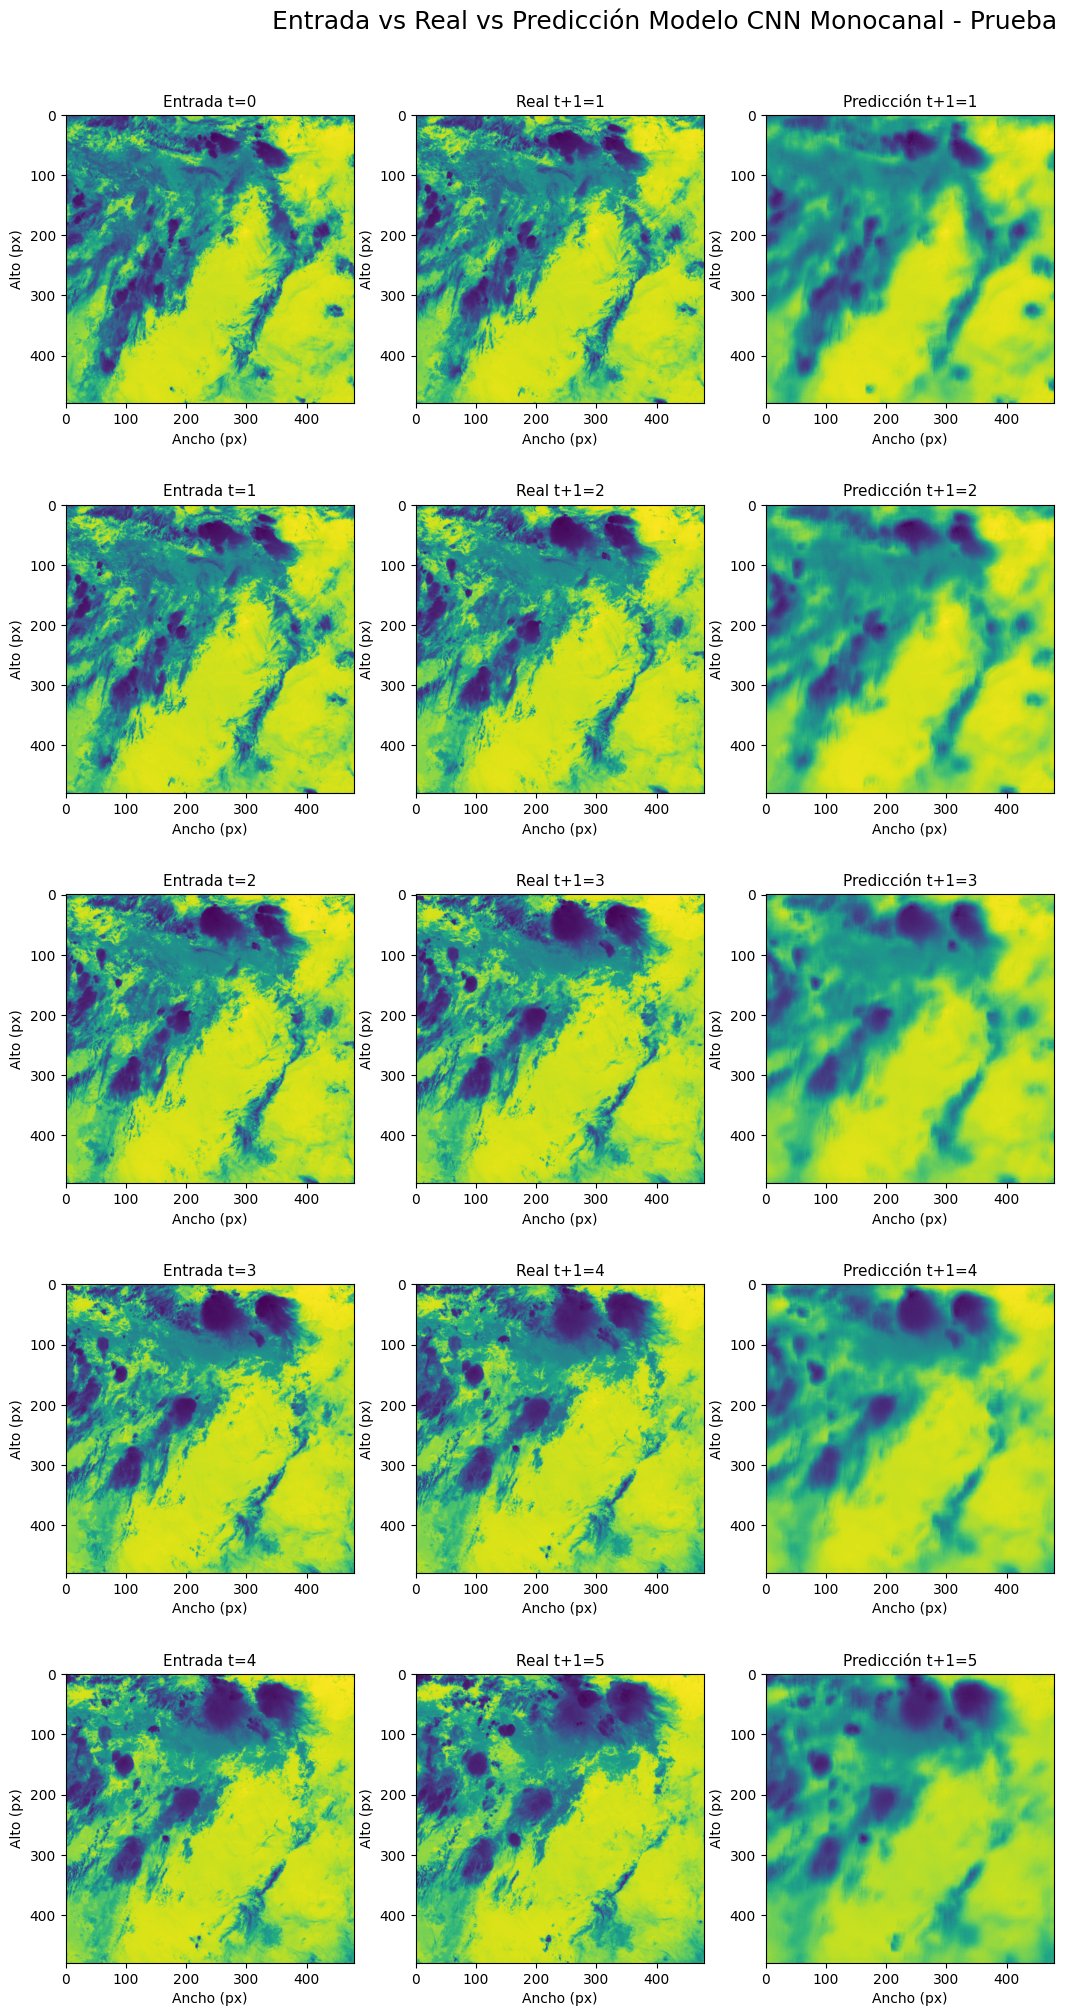

In [9]:
y_pred12_test = modelo_reconstruido.predict(X_test)  # Genera las predicciones
mostrar_resultados2(
    X_test, y_test, y_pred12_test, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo CNN Monocanal - Prueba",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step


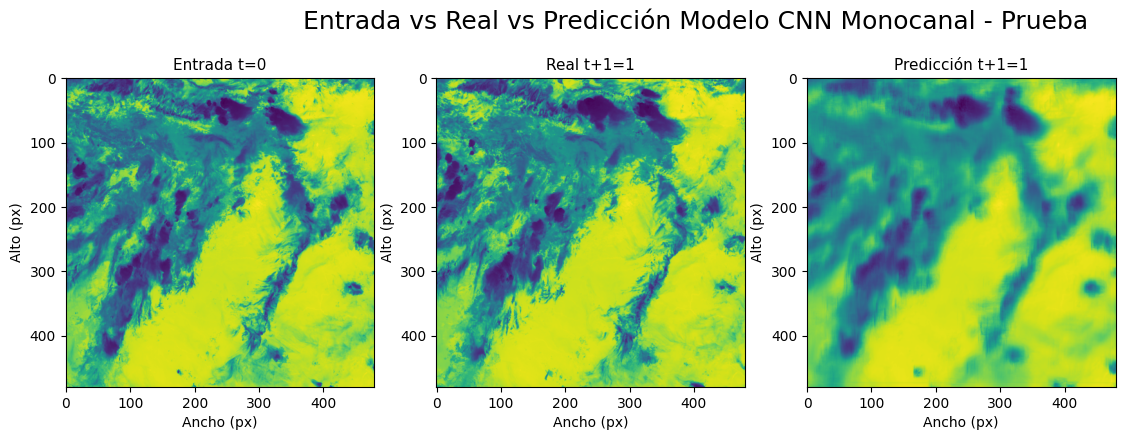

In [13]:
y_pred12_test = modelo_reconstruido.predict(X_test)  # Genera las predicciones
mostrar_resultados3(
    X_test, y_test, y_pred12_test, n=1,
    titulo_general="Entrada vs Real vs Predicción Modelo CNN Monocanal - Prueba",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)